In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(
    r"C:\Users\mahek\Desktop\Hack-O-Week\feb\PJME_hourly.csv"
)
print(df.head())
print(df.shape)

              Datetime  PJME_MW
0  2002-12-31 01:00:00  26498.0
1  2002-12-31 02:00:00  25147.0
2  2002-12-31 03:00:00  24574.0
3  2002-12-31 04:00:00  24393.0
4  2002-12-31 05:00:00  24860.0
(145366, 2)


In [ ]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df["hour"] = df["Datetime"].dt.hour
df["day"] = df["Datetime"].dt.day_name()
df["date"] = df["Datetime"].dt.date
df["is_weekend"] = df["day"].isin(["Saturday", "Sunday"]).astype(int)


In [20]:
q1 = df["PJME_MW"].quantile(0.25)
q2 = df["PJME_MW"].quantile(0.50)
q3 = df["PJME_MW"].quantile(0.75)


In [ ]:
df["category"] = np.select(
    [
        df["PJME_MW"] < q1,
        df["PJME_MW"] < q2,
        df["PJME_MW"] < q3
    ],
    ["Low", "Medium", "High"],
    default="Peak"
)
print(df["category"].value_counts())


category
High      36347
Medium    36343
Peak      36343
Low       36333
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
le_day = LabelEncoder()
le_cat = LabelEncoder()
df["day_enc"] = le_day.fit_transform(df["day"])
df["cat_enc"] = le_cat.fit_transform(df["category"])
scaler = StandardScaler()
df["power_scaled"] = scaler.fit_transform(df[["PJME_MW"]])


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
le_day = LabelEncoder()
le_cat = LabelEncoder()
df["day_enc"] = le_day.fit_transform(df["day"])
df["cat_enc"] = le_cat.fit_transform(df["category"])
scaler = StandardScaler()
df["power_scaled"] = scaler.fit_transform(df[["PJME_MW"]])


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


In [25]:
X = df[["hour", "day_enc", "is_weekend", "power_scaled"]]
y = df["cat_enc"]


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
y_pred = nb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Naive Bayes Accuracy:", round(accuracy * 100, 2), "%")

Naive Bayes Accuracy: 42.84 %


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "var_smoothing": np.logspace(-12, -6, 7)
}
grid = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring="accuracy"
)
grid.fit(X_train, y_train)
print("Best var_smoothing:", grid.best_params_)
print("Best CV Accuracy:", round(grid.best_score_ * 100, 2), "%")

Best var_smoothing: {'var_smoothing': np.float64(1e-12)}
Best CV Accuracy: 96.01 %


In [ ]:
best_nb = grid.best_estimator_
y_pred = best_nb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Final Naive Bayes Accuracy:", round(accuracy * 100, 2), "%")

Final Naive Bayes Accuracy: 95.83 %


In [29]:
from prophet import Prophet


c:\Users\mahek\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [30]:
daily = df.groupby("date")["PJME_MW"].sum().reset_index()
daily.columns = ["ds", "y"]

print(daily.head())


           ds         y
0  2002-01-01  714857.0
1  2002-01-02  822277.0
2  2002-01-03  828285.0
3  2002-01-04  809171.0
4  2002-01-05  729723.0


In [31]:
prophet_model = Prophet()
prophet_model.fit(daily)


10:53:42 - cmdstanpy - INFO - Chain [1] start processing
10:53:43 - cmdstanpy - INFO - Chain [1] done processing


In [32]:
future = prophet_model.make_future_dataframe(periods=7)
forecast = prophet_model.predict(future)


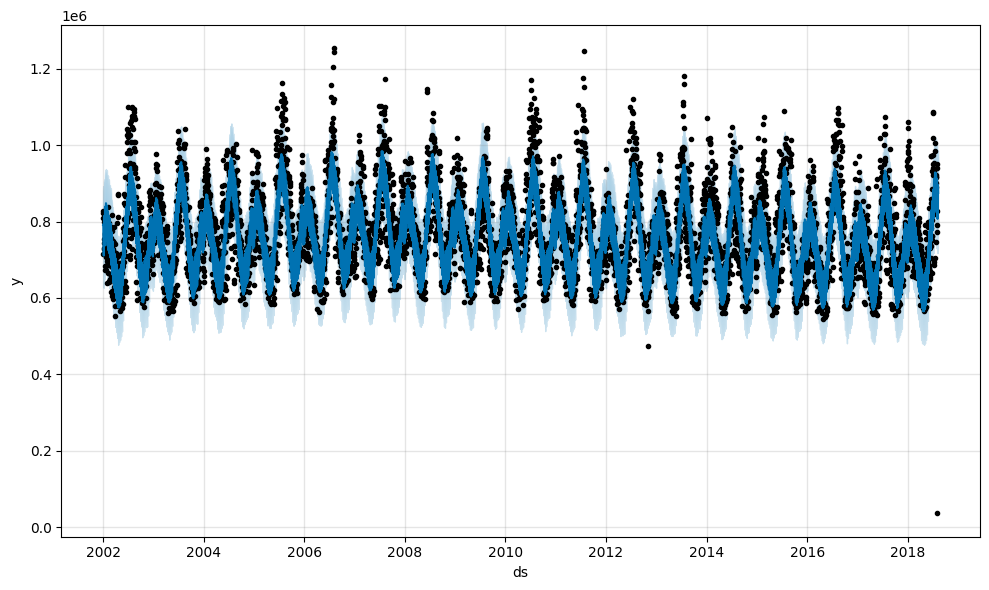

In [33]:
prophet_model.plot(forecast)
plt.show()


In [ ]:
import streamlit as st
import pandas as pd

st.title("Hostel Laundry Peak Prediction Dashboard")

st.metric(
    label="Naive Bayes Accuracy",
    value=f"{accuracy*100:.2f}%"
)

daily["ds"] = pd.to_datetime(daily["ds"])

date_range = st.slider(
    "Select Date Range",
    min_value=daily["ds"].min().to_pydatetime(),
    max_value=daily["ds"].max().to_pydatetime(),
    value=(
        daily["ds"].min().to_pydatetime(),
        daily["ds"].max().to_pydatetime()
    )
)

filtered = daily[
    (daily["ds"] >= date_range[0]) &
    (daily["ds"] <= date_range[1])
]

st.line_chart(filtered.set_index("ds"))


2026-02-19 10:55:05.164 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-19 10:55:05.165 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-19 10:55:05.165 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-19 10:55:05.165 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-19 10:55:05.165 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-19 10:55:05.165 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-19 10:55:05.172 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-19 10:55:05.174 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()